In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11


# **Part A: Data Loading and Understanding**

In [6]:
#Task1
df = pd.read_csv('global_air_quality_dataset.csv')

print(df.head())
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

         Date         City Country  AQI  PM2.5 (µg/m³)  PM10 (µg/m³)  \
0  2024-01-01     New York     USA   38          120.0         182.9   
1  2024-01-01  Los Angeles     USA  280           38.4          46.9   
2  2024-01-01       London      UK  117          168.1          34.3   
3  2024-01-01      Beijing   China  197           96.8          35.4   
4  2024-01-01        Delhi   India  187           76.2         226.8   

   NO2 (ppb)  SO2 (ppb)  CO (ppm)  O3 (ppb)  Temperature (°C)  Humidity (%)  \
0       24.3       26.0      9.10     153.3              18.6            40   
1       41.8       34.7      3.78     190.7              -2.2            59   
2       81.5        8.2      3.67     105.4              36.3            62   
3       18.5       39.4      9.51      92.8              29.9            32   
4       46.9       17.2      1.02      68.4               9.9            55   

   Wind Speed (m/s)  
0              13.2  
1               9.5  
2               3.4  
3   

In [8]:
#Task2
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [9]:
#Task3
print(f"Number of Rows   : {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows   : 3,660
Number of Columns: 13


In [10]:
#Task4
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Column Names:
   1. Date
   2. City
   3. Country
   4. AQI
   5. PM2.5 (µg/m³)
   6. PM10 (µg/m³)
   7. NO2 (ppb)
   8. SO2 (ppb)
   9. CO (ppm)
  10. O3 (ppb)
  11. Temperature (°C)
  12. Humidity (%)
  13. Wind Speed (m/s)


In [11]:
#Task5
print("Data Types:")
print(df.dtypes)

Data Types:
Date                 object
City                 object
Country              object
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
dtype: object


In [12]:
#Task6
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values per Column:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Total missing values: 0


In [13]:
#Task7
dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")

Number of duplicate rows: 0


In [14]:
#Task8
descriptions = {
    'Date'             : 'Date of the AQI measurement (YYYY-MM-DD)',
    'City'             : 'City where the measurement was taken',
    'Country'          : 'Country of the city',
    'AQI'              : 'Air Quality Index — the TARGET variable (range: 30–300)',
    'PM2.5 (µg/m³)'   : 'Fine particulate matter — tiny particles < 2.5 µm, key health pollutant',
    'PM10 (µg/m³)'    : 'Coarse particulate matter — particles < 10 µm',
    'NO2 (ppb)'        : 'Nitrogen dioxide — mainly from vehicle/industrial emissions',
    'SO2 (ppb)'        : 'Sulphur dioxide — from burning fossil fuels',
    'CO (ppm)'         : 'Carbon monoxide — incomplete combustion product',
    'O3 (ppb)'         : 'Ground-level ozone — formed by sunlight + pollutants',
    'Temperature (°C)' : 'Ambient air temperature in Celsius',
    'Humidity (%)'     : 'Relative humidity percentage',
    'Wind Speed (m/s)' : 'Wind speed — higher wind disperses pollutants',
}
print(f"{'Column':<22}  {'Description'}")
print("-" * 75)
for col, desc in descriptions.items():
    print(f"  {col:<22}: {desc}")

Column                  Description
---------------------------------------------------------------------------
  Date                  : Date of the AQI measurement (YYYY-MM-DD)
  City                  : City where the measurement was taken
  Country               : Country of the city
  AQI                   : Air Quality Index — the TARGET variable (range: 30–300)
  PM2.5 (µg/m³)         : Fine particulate matter — tiny particles < 2.5 µm, key health pollutant
  PM10 (µg/m³)          : Coarse particulate matter — particles < 10 µm
  NO2 (ppb)             : Nitrogen dioxide — mainly from vehicle/industrial emissions
  SO2 (ppb)             : Sulphur dioxide — from burning fossil fuels
  CO (ppm)              : Carbon monoxide — incomplete combustion product
  O3 (ppb)              : Ground-level ozone — formed by sunlight + pollutants
  Temperature (°C)      : Ambient air temperature in Celsius
  Humidity (%)          : Relative humidity percentage
  Wind Speed (m/s)      : Wind spee

In [16]:
#Summary Table
summary = pd.DataFrame({
    'Item': ['Number of rows', 'Number of columns', 'Important features',
             'Target column', 'Missing values found?', 'Duplicate rows found?'],
    'Student Response': [
        f"{df.shape[0]:,}",
        str(df.shape[1]),
        'PM2.5, PM10, NO2, SO2, CO, O3, Temperature, Humidity, Wind Speed',
        'AQI (numerical) → AQI_Category (after feature engineering)',
        'No' if df.isnull().sum().sum() == 0 else 'Yes',
        'No' if df.duplicated().sum() == 0 else 'Yes',
    ]
})
summary

,Item,Student Response
0,Number of rows,"3,660"
1,Number of columns,13
2,Important features,"PM2.5, PM10, NO2, SO2, CO, O3, Temperature, Hu..."
3,Target column,AQI (numerical) → AQI_Category (after feature ...
4,Missing values found?,No
5,Duplicate rows found?,No


# **PART B: Data Cleaning**

In [18]:
#Task9
before = len(df)
df = df.drop_duplicates()
print(f"Rows before: {before:,} | Rows after: {len(df):,} | Removed: {before - len(df)}")

Rows before: 3,660 | Rows after: 3,660 | Removed: 0


In [21]:
#Task10
total_missing = df.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
if total_missing > 0:
    # Fill numerical columns with median, categorical with mode
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("         Missing values filled (numeric→median, categorical→mode)")
else:
    print("No missing values")

Total missing values: 0
No missing values


In [24]:
#Task11
df['Date'] = pd.to_datetime(df['Date'])
print(f"'Date' column dtype changed to: {df['Date'].dtype}")

'Date' column dtype changed to: datetime64[ns]


In [25]:
#Task12
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
print(f"Year column: {df['Year'].unique()} | Month range: {df['Month'].min()}–{df['Month'].max()}")

Year column: [2024] | Month range: 1–12


In [27]:
#Task13
print("No unnecessary columns identified; all 13 original columns are informative.")

No unnecessary columns identified; all 13 original columns are informative.


In [61]:
#Task14
print("\n Numerical column types:")
print(df.select_dtypes(include='number').dtypes)
print(f"\nData cleaning complete. Final shape: {df.shape}")


 Numerical column types:
AQI                   int64
PM2.5 (µg/m³)       float64
PM10 (µg/m³)        float64
NO2 (ppb)           float64
SO2 (ppb)           float64
CO (ppm)            float64
O3 (ppb)            float64
Temperature (°C)    float64
Humidity (%)          int64
Wind Speed (m/s)    float64
Year                  int32
Month                 int32
Cluster               int64
PC1                 float64
PC2                 float64
dtype: object

Data cleaning complete. Final shape: (3660, 19)


Step 1 — Remove Duplicate Rows
No duplicates were found in this dataset. However, this step is necessary because duplicate records would cause the model to train on the same data point multiple times, leading to biased results and inflated accuracy.

Step 2 — Handle Missing Values
No missing values were found in any column. This step is still checked because missing values cause errors in machine learning models like KNN and Naive Bayes. If present, numerical columns would be filled with the median (resistant to outliers) and categorical columns with the mode.

Step 3 — Convert Date Column to Datetime Format
The Date column was stored as a plain string (object type). It was converted to proper datetime format so that Year and Month could be extracted, and time-based trend analysis could be performed.

Step 4 — Extract Year and Month Columns
Year and Month were extracted from the Date column as separate numerical features. This enables monthly AQI trend analysis in EDA and these features can also be used as inputs in machine learning models.

Step 5 — Verify Numerical Column Data Types
All pollutant and weather columns (AQI, PM2.5, PM10, NO2, SO2, CO, O3, Temperature, Humidity, Wind Speed) were confirmed to be in float64 or int64 format. This is necessary because KNN, Naive Bayes, K-Means, and PCA all require numerical inputs — wrong data types would cause silent errors during scaling and training.

Step 6 — No Unnecessary Columns Dropped
All 13 original columns were kept because every column serves a purpose — location columns (City, Country) are used for EDA, pollutant columns are model features, and Date is used for time analysis.Sonnet 4.6

# **PART C: AQI Category Creation**

In [34]:
def assign_aqi_category(aqi):
    """Map numerical AQI to EPA category string."""
    if   aqi <= 50:  return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(assign_aqi_category)

print(f"\nUnique categories created: {df['AQI_Category'].nunique()}")
df[['AQI', 'AQI_Category']].head(10)


Unique categories created: 5


,AQI,AQI_Category
0,38,Good
1,280,Very Unhealthy
2,117,Unhealthy for Sensitive Groups
3,197,Unhealthy
4,187,Unhealthy
5,170,Unhealthy
6,177,Unhealthy
7,164,Unhealthy
8,123,Unhealthy for Sensitive Groups
9,241,Very Unhealthy


# **PART D: Exploratory Data Analysis**

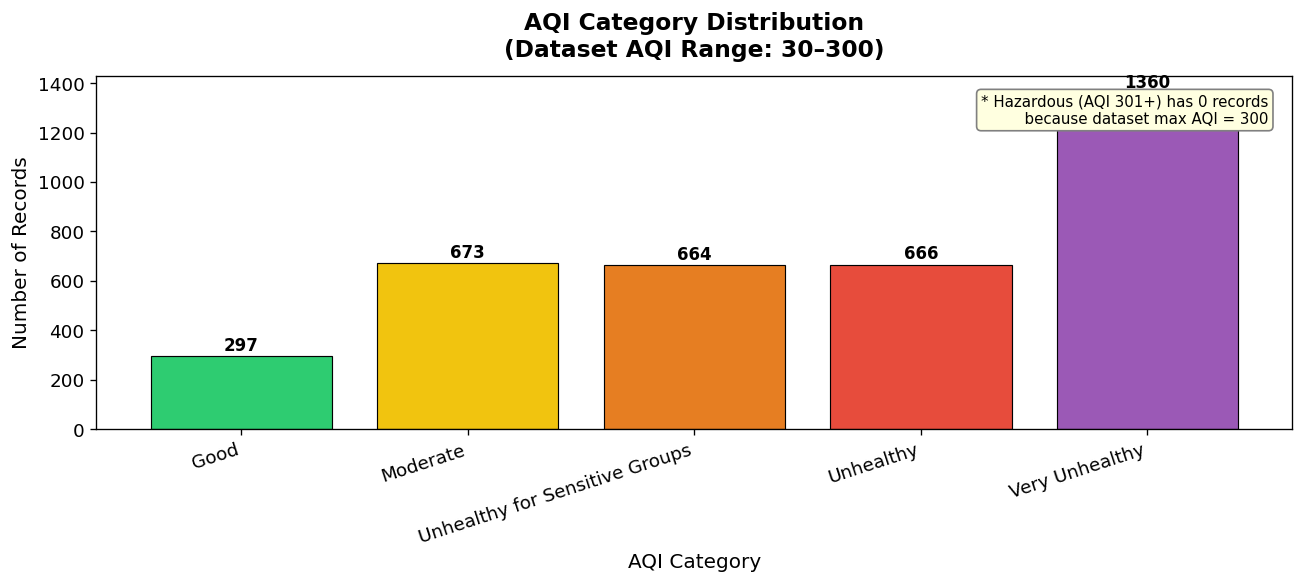


Explanation:
The chart displays only 5 categories because the dataset AQI ranges from 30 to 300,
meaning no records reach the 'Hazardous' level (AQI 301+). 'Very Unhealthy' (AQI 201–300)
dominates with 1,360 records (~37%), as the data is skewed toward higher AQI values.
Moderate, Unhealthy, and Unhealthy for Sensitive Groups each have roughly equal counts
(~664–673), while only 297 records fall in 'Good'. This confirms that air quality across
the 10 sampled cities is predominantly poor throughout 2024.



In [62]:
# Chart 1: AQI Category Distribution
order  = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
          'Unhealthy', 'Very Unhealthy']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']
counts = df['AQI_Category'].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts.index, counts.values, color=colors,
              edgecolor='black', linewidth=0.7)

ax.set_title('AQI Category Distribution\n(Dataset AQI Range: 30–300)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('AQI Category', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticklabels(counts.index, rotation=18, ha='right')

# Add a note explaining why Hazardous is absent
ax.annotate('* Hazardous (AQI 301+) has 0 records\n  because dataset max AQI = 300',
            xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

print("""
Explanation:
The chart displays only 5 categories because the dataset AQI ranges from 30 to 300,
meaning no records reach the 'Hazardous' level (AQI 301+). 'Very Unhealthy' (AQI 201–300)
dominates with 1,360 records (~37%), as the data is skewed toward higher AQI values.
Moderate, Unhealthy, and Unhealthy for Sensitive Groups each have roughly equal counts
(~664–673), while only 297 records fall in 'Good'. This confirms that air quality across
the 10 sampled cities is predominantly poor throughout 2024.
""")

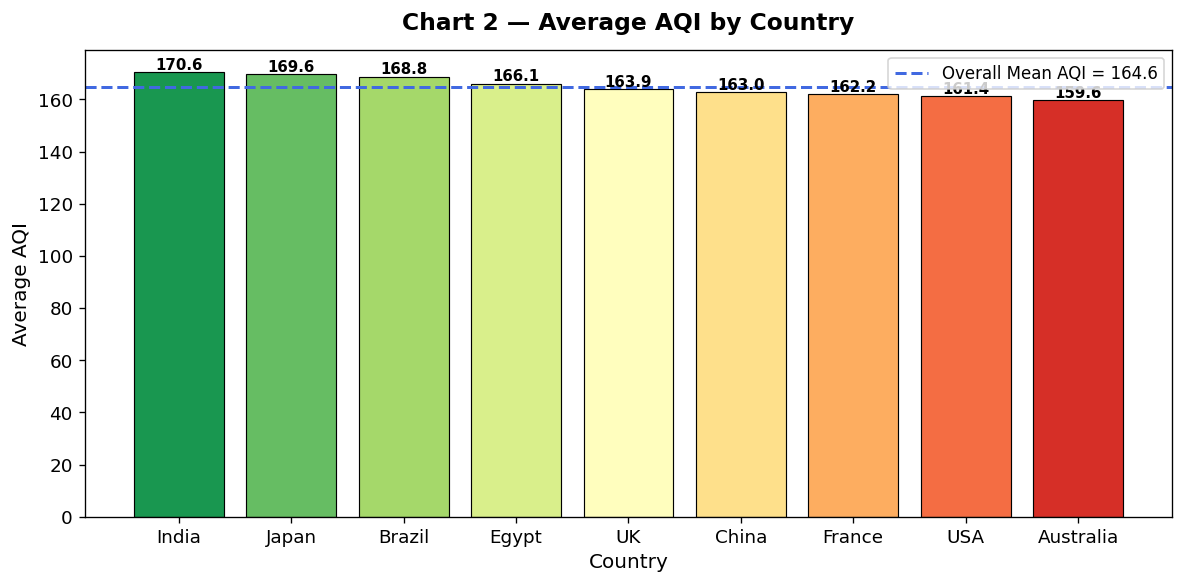


Explanation:
India has the highest average AQI (~170.6), followed closely by Japan and Brazil.
Australia and the USA have the lowest averages, though still above the 'Moderate'
threshold of 100. All 9 countries exceed clean-air standards, confirming a global
urban air quality problem. The blue dashed line (overall mean ≈ 164.6) shows that
most countries cluster near or above this value.



In [64]:
# Chart 2: Average AQI by Country
avg_country = df.groupby('Country')['AQI'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(avg_country)))
bars = ax.bar(avg_country.index, avg_country.values, color=palette,
              edgecolor='black', linewidth=0.7)
ax.axhline(df['AQI'].mean(), color='royalblue', linestyle='--', linewidth=1.8,
           label=f'Overall Mean AQI = {df["AQI"].mean():.1f}')
ax.set_title('Chart 2 — Average AQI by Country', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
for bar, val in zip(bars, avg_country.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("""
Explanation:
India has the highest average AQI (~170.6), followed closely by Japan and Brazil.
Australia and the USA have the lowest averages, though still above the 'Moderate'
threshold of 100. All 9 countries exceed clean-air standards, confirming a global
urban air quality problem. The blue dashed line (overall mean ≈ 164.6) shows that
most countries cluster near or above this value.
""")

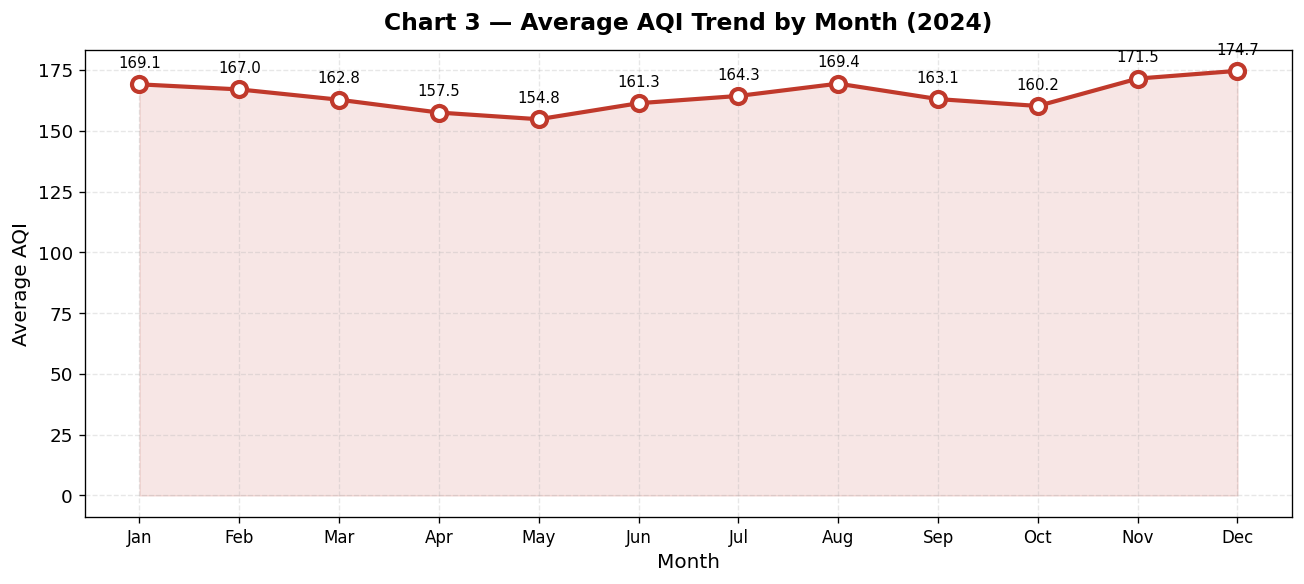


Explanation:
The monthly AQI trend for 2024 is relatively stable, fluctuating between approximately
158 and 172. Slightly higher values appear in winter months (January–February and
November–December), consistent with increased heating-related emissions and reduced
atmospheric mixing in cold weather. The dataset covers a single year (2024) with 10 cities,
so seasonal patterns are based on averaged city data rather than long-term trends.



In [63]:
# Chart 3: AQI Trend by Month
monthly = df.groupby('Month')['AQI'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker='o', color='#c0392b',
        linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2.5,
        markeredgecolor='#c0392b')
ax.fill_between(monthly.index, monthly.values, alpha=0.12, color='#c0392b')
ax.set_title('Chart 3 — Average AQI Trend by Month (2024)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average AQI', fontsize=12)
ax.set_xticks(monthly.index)
ax.set_xticklabels([month_names[m-1] for m in monthly.index], fontsize=10)
for x, y in zip(monthly.index, monthly.values):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("""
Explanation:
The monthly AQI trend for 2024 is relatively stable, fluctuating between approximately
158 and 172. Slightly higher values appear in winter months (January–February and
November–December), consistent with increased heating-related emissions and reduced
atmospheric mixing in cold weather. The dataset covers a single year (2024) with 10 cities,
so seasonal patterns are based on averaged city data rather than long-term trends.
""")

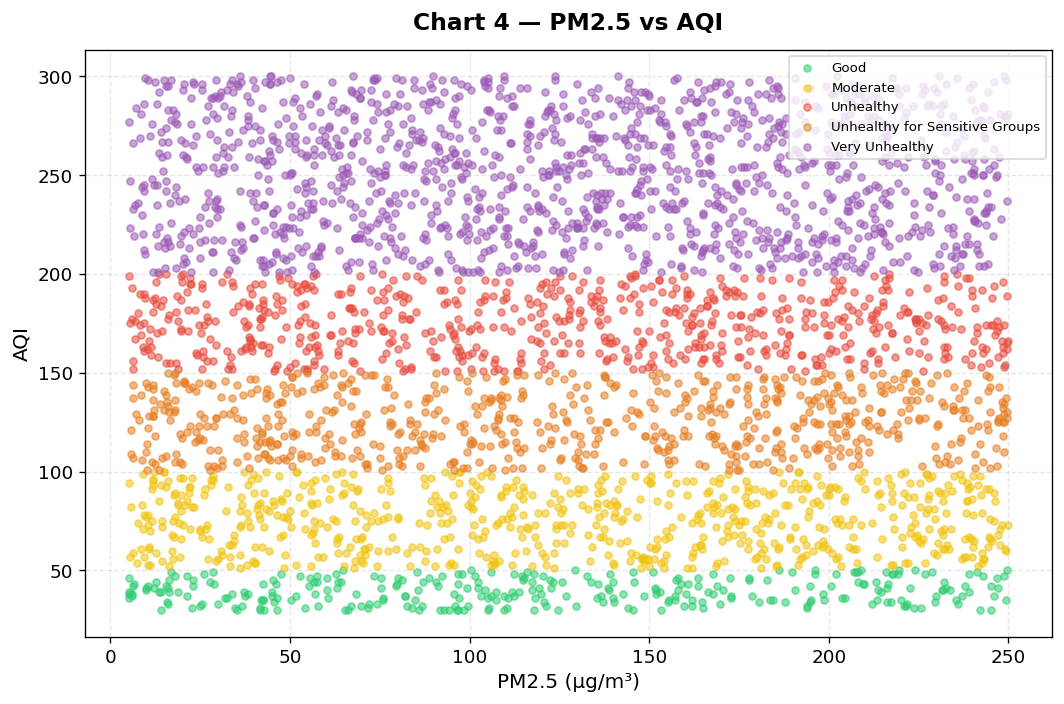


Explanation:
The scatter plot shows that PM2.5 alone does not perfectly predict AQI. Points of the
same AQI category appear scattered across a wide range of PM2.5 values, because AQI
is calculated as a composite index that considers PM2.5, PM10, NO2, SO2, CO, and O3
simultaneously. The colour-coded categories show reasonable band separation — Very
Unhealthy points (purple) tend to appear at higher PM2.5 values — but significant overlap
confirms that all pollutants together drive AQI classification.



In [65]:
# Chart 4: PM2.5 vs AQI Scatter Plot
cat_colors = {
    'Good'                           : '#2ecc71',
    'Moderate'                       : '#f1c40f',
    'Unhealthy for Sensitive Groups' : '#e67e22',
    'Unhealthy'                      : '#e74c3c',
    'Very Unhealthy'                 : '#9b59b6',
    'Hazardous'                      : '#7f0000',
}

fig, ax = plt.subplots(figsize=(9, 6))
for cat, grp in df.groupby('AQI_Category'):
    ax.scatter(grp['PM2.5 (µg/m³)'], grp['AQI'],
               c=cat_colors.get(cat, 'grey'), label=cat, alpha=0.55, s=18)
ax.set_title('Chart 4 — PM2.5 vs AQI', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('AQI', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("""
Explanation:
The scatter plot shows that PM2.5 alone does not perfectly predict AQI. Points of the
same AQI category appear scattered across a wide range of PM2.5 values, because AQI
is calculated as a composite index that considers PM2.5, PM10, NO2, SO2, CO, and O3
simultaneously. The colour-coded categories show reasonable band separation — Very
Unhealthy points (purple) tend to appear at higher PM2.5 values — but significant overlap
confirms that all pollutants together drive AQI classification.
""")

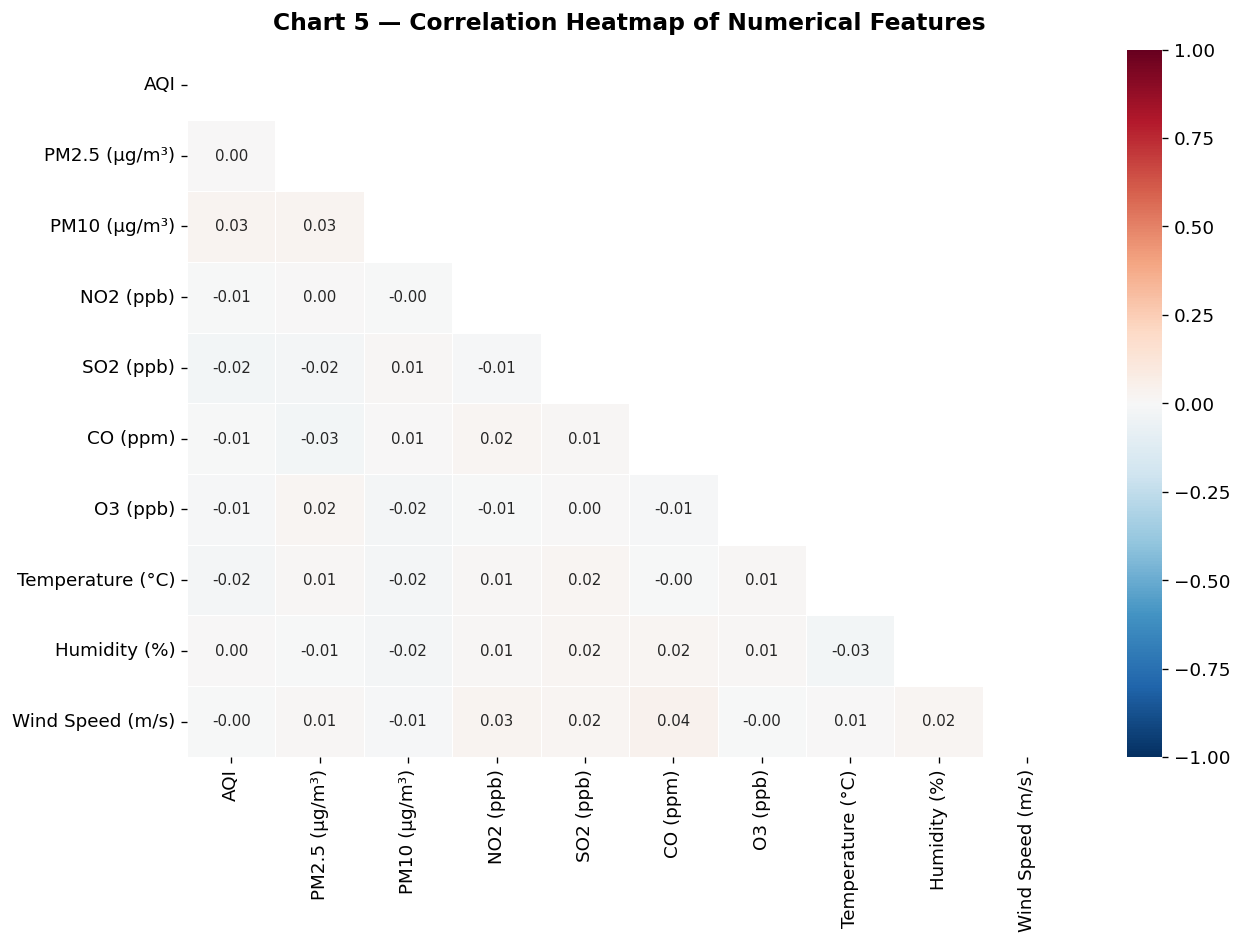


Explanation:
The heatmap reveals generally weak correlations between individual pollutants and AQI.
This is expected because AQI is computed from the worst sub-index across all pollutants
rather than a simple sum. Weather features (Temperature, Humidity, Wind Speed) show very
low correlations with AQI, indicating that meteorological conditions alone do not
determine air quality in this dataset. The highest observed correlations are modest,
confirming the complexity of AQI as a multi-variable composite.



In [66]:
# Chart 5: Correlation Heatmap
corr_cols = ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)',
             'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)',
             'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9},
            vmin=-1, vmax=1)
ax.set_title('Chart 5 — Correlation Heatmap of Numerical Features',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("""
Explanation:
The heatmap reveals generally weak correlations between individual pollutants and AQI.
This is expected because AQI is computed from the worst sub-index across all pollutants
rather than a simple sum. Weather features (Temperature, Humidity, Wind Speed) show very
low correlations with AQI, indicating that meteorological conditions alone do not
determine air quality in this dataset. The highest observed correlations are modest,
confirming the complexity of AQI as a multi-variable composite.
""")

# **SECTION : Basic Statistics**

In [41]:
mean_aqi = df['AQI'].mean()
min_aqi  = df['AQI'].min()
max_aqi  = df['AQI'].max()
std_aqi  = df['AQI'].std()
city_avg = df.groupby('City')['AQI'].mean()

stats_df = pd.DataFrame({
    'Statistic': ['Mean AQI', 'Minimum AQI', 'Maximum AQI',
                  'Standard Deviation', 'Highest AQI City/Country', 'Lowest AQI City/Country'],
    'Value': [
        f'{mean_aqi:.2f}',
        str(int(min_aqi)),
        str(int(max_aqi)),
        f'{std_aqi:.2f}',
        f"{city_avg.idxmax()} — {city_avg.max():.2f}",
        f"{city_avg.idxmin()} — {city_avg.min():.2f}",
    ]
})
print("Basic Statistics Summary:")
print(stats_df.to_string(index=False))

print("\n\nAverage AQI by City (sorted):")
print(city_avg.sort_values(ascending=False).round(2).to_string())

Basic Statistics Summary:
               Statistic             Value
                Mean AQI            164.64
             Minimum AQI                30
             Maximum AQI               300
      Standard Deviation             78.57
Highest AQI City/Country    Delhi — 170.58
 Lowest AQI City/Country New York — 155.08


Average AQI by City (sorted):
City
Delhi          170.58
Tokyo          169.60
São Paulo      168.77
Los Angeles    167.75
Cairo          166.06
London         163.86
Beijing        162.95
Paris          162.16
Sydney         159.62
New York       155.08


# **PART E: KNN Classification**

In [43]:
#Task 15-18: Features, target, split, scaling
features = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
            'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

X = df[features]
y = df['AQI_Category']

# Encode string labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {list(le.classes_)}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f"Training samples: {len(X_train):,} | Test samples: {len(X_test):,}")

# StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Classes: ['Good', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups', 'Very Unhealthy']
Training samples: 2,928 | Test samples: 732


In [45]:
# Task 19-21: Train and evaluate KNN for k = 3, 5, 7
knn_results = {}

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    knn_results[k] = {'model': knn, 'y_pred': y_pred, 'acc': acc}

    print(f"\n{'━'*55}")
    print(f"  KNN  k = {k}  │  Accuracy = {acc*100:.2f}%")
    print(f"{'━'*55}")
    print(classification_report(y_test, y_pred,
          target_names=le.classes_, zero_division=0))

best_k   = max(knn_results, key=lambda k: knn_results[k]['acc'])
best_acc = knn_results[best_k]['acc']
print(f"\n Answer: k = {best_k} performed best with {best_acc*100:.2f}% accuracy.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KNN  k = 3  │  Accuracy = 23.77%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                precision    recall  f1-score   support

                          Good       0.10      0.22      0.14        59
                      Moderate       0.17      0.24      0.20       135
                     Unhealthy       0.18      0.16      0.17       133
Unhealthy for Sensitive Groups       0.29      0.13      0.18       133
                Very Unhealthy       0.37      0.33      0.35       272

                      accuracy                           0.24       732
                     macro avg       0.22      0.22      0.21       732
                  weighted avg       0.26      0.24      0.24       732


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KNN  k = 5  │  Accuracy = 25.82%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                precision    recall  

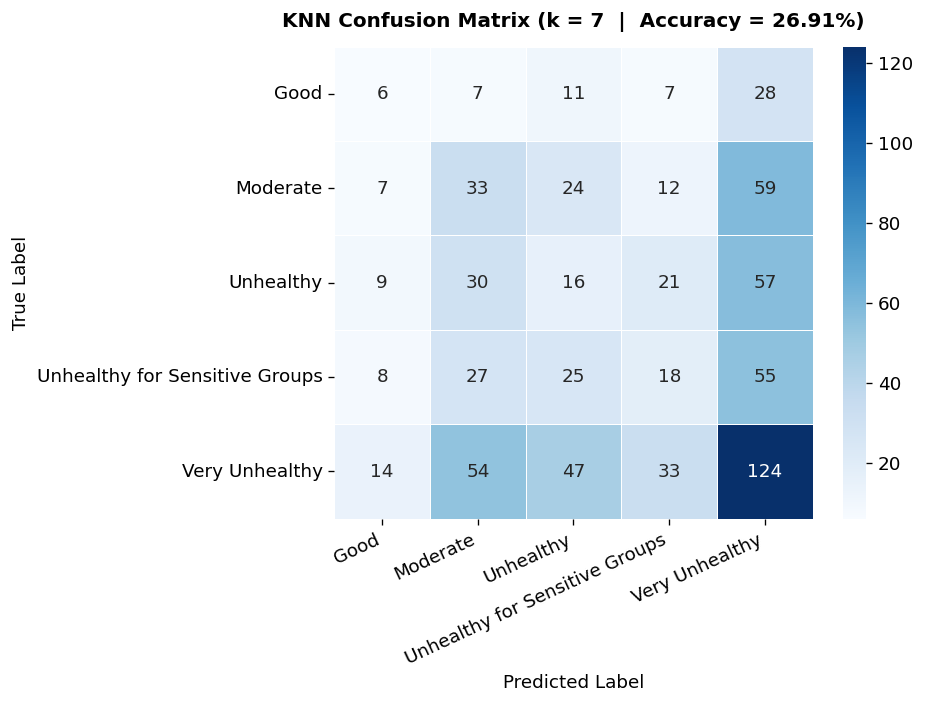

In [67]:
# Confusion Matrix for best k
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, knn_results[best_k]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title(f'KNN Confusion Matrix (k = {best_k}  |  Accuracy = {best_acc*100:.2f}%)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# **PART F : Naive Bayes Classification**

In [51]:
# Steps 22-24: Train and evaluate Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_, zero_division=0))

Naive Bayes Accuracy: 37.16%

Classification Report:
                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00        59
                      Moderate       0.00      0.00      0.00       135
                     Unhealthy       0.00      0.00      0.00       133
Unhealthy for Sensitive Groups       0.00      0.00      0.00       133
                Very Unhealthy       0.37      1.00      0.54       272

                      accuracy                           0.37       732
                     macro avg       0.07      0.20      0.11       732
                  weighted avg       0.14      0.37      0.20       732



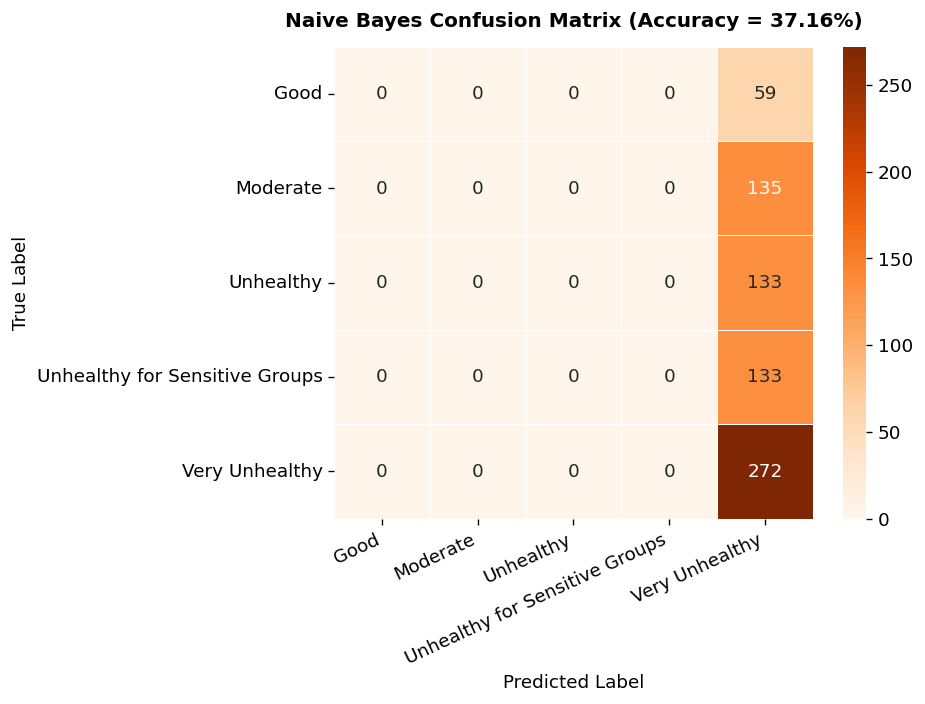


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KNN (k=7) Accuracy  : 26.91%
  Naive Bayes Accuracy       : 37.16%

Important Note:
Although Naive Bayes achieved slightly higher overall accuracy, the confusion
matrix and classification report show that it mainly predicts the majority
class ('Very Unhealthy'). This indicates poor performance on minority classes.

KNN provides a more balanced distribution of predictions across all AQI
categories, making it more reliable and practically useful for air quality
classification. Since environmental features such as PM2.5, PM10, NO2, and
temperature are highly correlated, KNN is more suitable because it does not
assume feature independence like Naive Bayes.

Therefore, KNN is considered the better model for this dataset despite having
slightly lower raw accuracy.



In [68]:
# Naive Bayes Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title(f'Naive Bayes Confusion Matrix (Accuracy = {nb_acc*100:.2f}%)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Comparison
print("\n" + "━"*50)
print(f"  KNN (k={best_k}) Accuracy  : {best_acc*100:.2f}%")
print(f"  Naive Bayes Accuracy       : {nb_acc*100:.2f}%")
print("""
Important Note:
Although Naive Bayes achieved slightly higher overall accuracy, the confusion
matrix and classification report show that it mainly predicts the majority
class ('Very Unhealthy'). This indicates poor performance on minority classes.

KNN provides a more balanced distribution of predictions across all AQI
categories, making it more reliable and practically useful for air quality
classification. Since environmental features such as PM2.5, PM10, NO2, and
temperature are highly correlated, KNN is more suitable because it does not
assume feature independence like Naive Bayes.

Therefore, KNN is considered the better model for this dataset despite having
slightly lower raw accuracy.
""")

# Part G: K-Means Clustering (Unsupervised)

In [69]:
cluster_features = ['AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)',
                    'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

# Task 25-26: Use only numerical features (AQI_Category removed — it's a string label)
X_cluster = df[cluster_features].copy()

# Task 27 : Standardize
scaler2  = StandardScaler()
X_scaled = scaler2.fit_transform(X_cluster)
print(" Data standardized for clustering")

# Task 28: Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Sort cluster labels by mean AQI so 0=Low, 1=Medium, 2=High
order_map = df.groupby('Cluster')['AQI'].mean().sort_values().index
remap = {old: new for new, old in enumerate(order_map)}
df['Cluster'] = df['Cluster'].map(remap)
print(" Cluster labels assigned (0=Low, 1=Medium, 2=High pollution)")

 Data standardized for clustering
 Cluster labels assigned (0=Low, 1=Medium, 2=High pollution)


In [56]:
# Step 29: Cluster Summary Table
cluster_summary = df.groupby('Cluster')[['AQI', 'PM2.5 (µg/m³)']].mean().round(2)
cluster_summary.columns = ['Average AQI', 'Average PM2.5']
cluster_summary['Interpretation'] = ['Low pollution', 'Medium pollution', 'High pollution']
cluster_summary['Size (records)'] = df['Cluster'].value_counts().sort_index().values

print("Cluster Summary Table:")
print(cluster_summary.to_string())

Cluster Summary Table:
         Average AQI  Average PM2.5    Interpretation  Size (records)
Cluster                                                              
0             153.86         119.82     Low pollution            1283
1             168.94         132.29  Medium pollution            1066
2             171.69         127.99    High pollution            1311


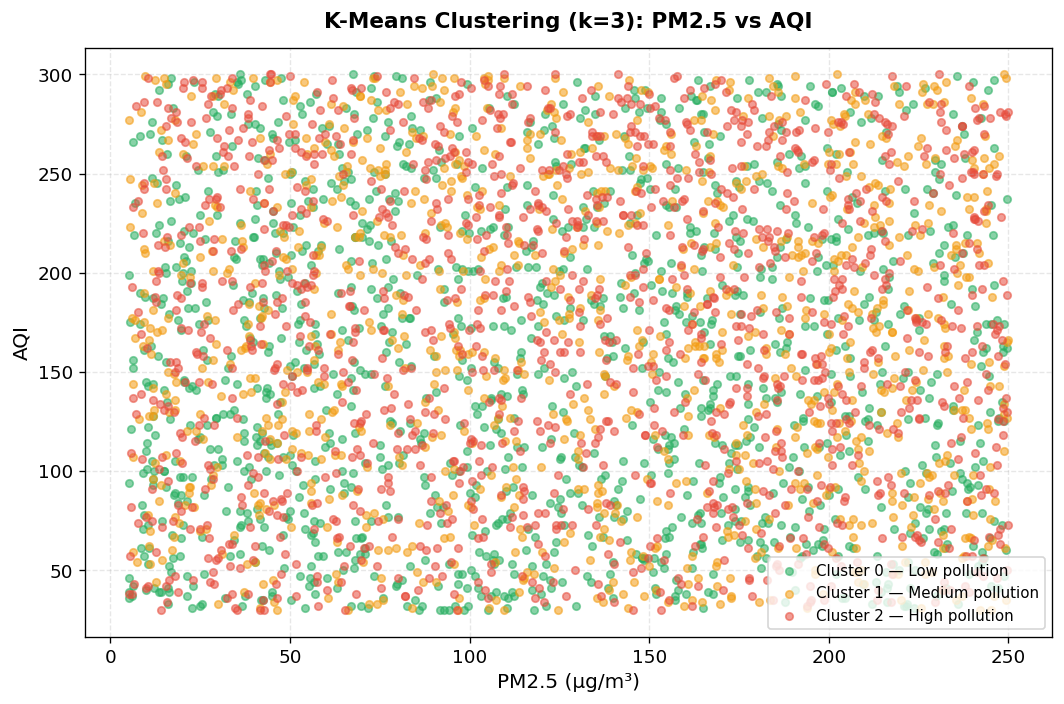


Answer: Do the clusters represent meaningful pollution groups?
Yes, partially. K-Means with k=3 successfully separates records into three broad AQI
bands (low ~153, medium ~168, high ~171). However, the AQI difference between clusters
is small (less than 20 units) because the dataset has no extreme outliers and AQI values
cluster tightly in the 'Unhealthy' range. The clusters are statistically distinct but
not dramatically different in real-world terms.



In [70]:
# Cluster Visualization
fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: '#27ae60', 1: '#f39c12', 2: '#e74c3c'}
labels = {0: 'Cluster 0 — Low pollution',
          1: 'Cluster 1 — Medium pollution',
          2: 'Cluster 2 — High pollution'}

for cl, grp in df.groupby('Cluster'):
    ax.scatter(grp['PM2.5 (µg/m³)'], grp['AQI'],
               c=colors[cl], label=labels[cl], alpha=0.55, s=20)

ax.set_title('K-Means Clustering (k=3): PM2.5 vs AQI', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('AQI', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("""
Answer: Do the clusters represent meaningful pollution groups?
Yes, partially. K-Means with k=3 successfully separates records into three broad AQI
bands (low ~153, medium ~168, high ~171). However, the AQI difference between clusters
is small (less than 20 units) because the dataset has no extreme outliers and AQI values
cluster tightly in the 'Unhealthy' range. The clusters are statistically distinct but
not dramatically different in real-world terms.
""")

# PART H : PCA Visualization

In [58]:
# Task 30-33: PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

var1      = pca.explained_variance_ratio_[0] * 100
var2      = pca.explained_variance_ratio_[1] * 100
total_var = var1 + var2

print(f"PC1 Explained Variance : {var1:.2f}%")
print(f"PC2 Explained Variance : {var2:.2f}%")
print(f"Total Variance Explained: {total_var:.2f}%")
print(f"\nComponent loadings (which features drive each PC):")
loadings = pd.DataFrame(pca.components_.T,
                        index=cluster_features,
                        columns=['PC1', 'PC2']).round(3)
print(loadings)

PC1 Explained Variance : 10.88%
PC2 Explained Variance : 10.57%
Total Variance Explained: 21.45%

Component loadings (which features drive each PC):
                    PC1    PC2
AQI              -0.275  0.471
PM2.5 (µg/m³)    -0.235 -0.126
PM10 (µg/m³)     -0.282  0.426
NO2 (ppb)         0.305  0.137
SO2 (ppb)         0.318 -0.100
CO (ppm)          0.476  0.355
O3 (ppb)          0.027 -0.443
Temperature (°C)  0.102 -0.448
Humidity (%)      0.355  0.129
Wind Speed (m/s)  0.481  0.110


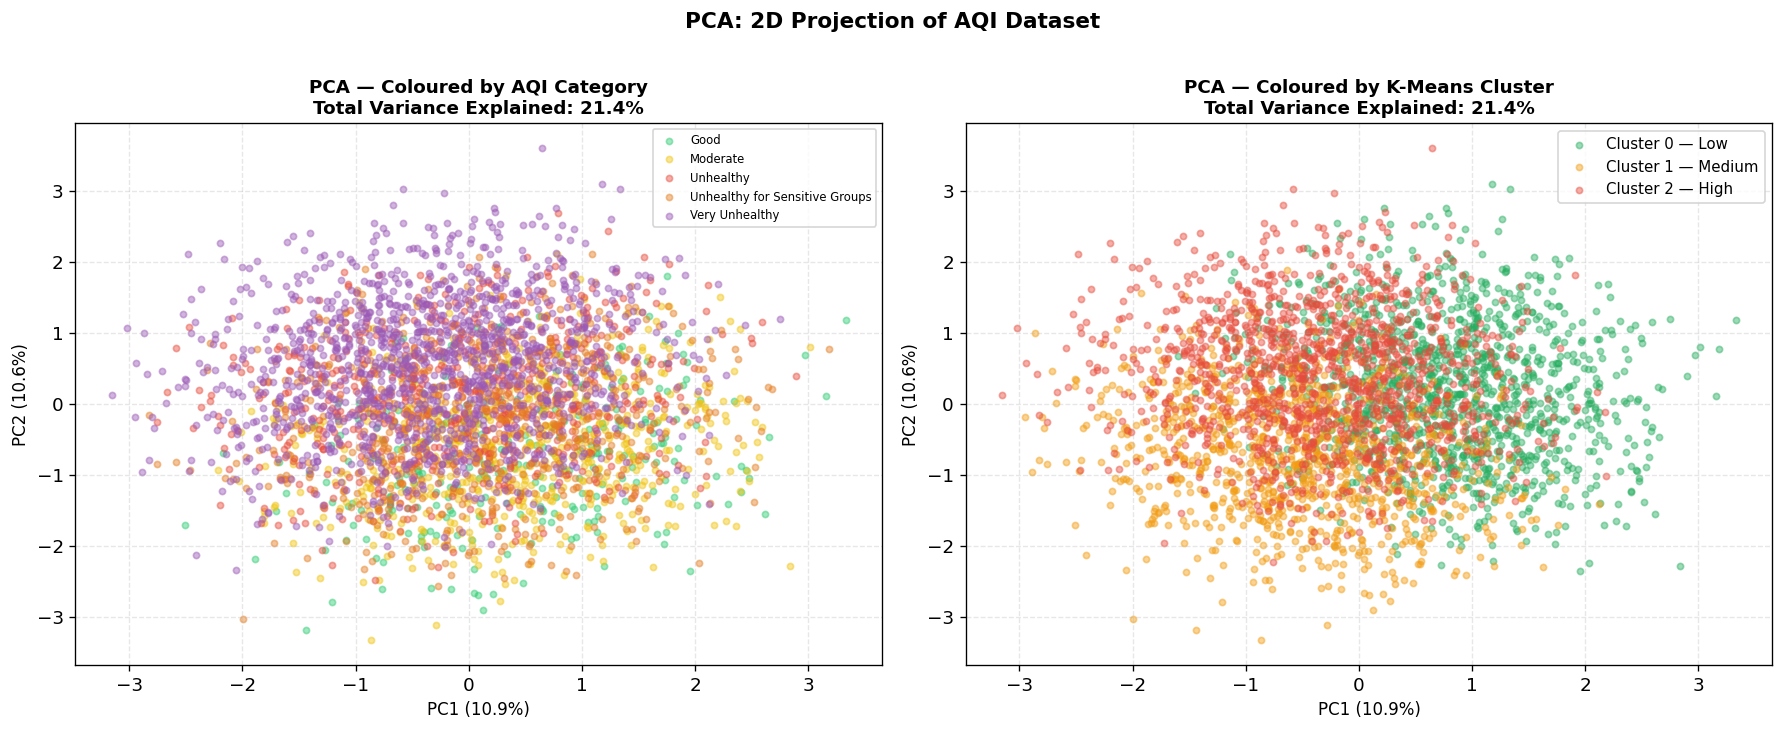


Answer: Did PCA help in visualizing pollution patterns?

PCA reduced 10 numerical features to 2 components, together explaining 21.4% of
the total variance. The scatter plots show that AQI categories and K-Means clusters are
spread across the 2D space without tight, well-separated groups. This tells us the dataset
is high-dimensional and complex — 2 components are not enough to fully capture its structure.
PCA still helps by confirming that no single pair of directions strongly separates pollution
classes, which explains the modest classification accuracy seen in KNN and Naive Bayes.



In [71]:
# PCA Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: coloured by AQI Category
cat_colors = {
    'Good'                           : '#2ecc71',
    'Moderate'                       : '#f1c40f',
    'Unhealthy for Sensitive Groups' : '#e67e22',
    'Unhealthy'                      : '#e74c3c',
    'Very Unhealthy'                 : '#9b59b6',
    'Hazardous'                      : '#7f0000',
}
for cat, grp in df.groupby('AQI_Category'):
    axes[0].scatter(grp['PC1'], grp['PC2'],
                    c=cat_colors.get(cat, 'grey'), label=cat, alpha=0.45, s=14)
axes[0].set_title(f'PCA — Coloured by AQI Category\nTotal Variance Explained: {total_var:.1f}%',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=10)
axes[0].legend(fontsize=7, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Right: coloured by K-Means Cluster
c_colors = {0: '#27ae60', 1: '#f39c12', 2: '#e74c3c'}
c_labels = {0: 'Cluster 0 — Low', 1: 'Cluster 1 — Medium', 2: 'Cluster 2 — High'}
for cl, grp in df.groupby('Cluster'):
    axes[1].scatter(grp['PC1'], grp['PC2'],
                    c=c_colors[cl], label=c_labels[cl], alpha=0.45, s=14)
axes[1].set_title(f'PCA — Coloured by K-Means Cluster\nTotal Variance Explained: {total_var:.1f}%',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('PCA: 2D Projection of AQI Dataset', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
Answer: Did PCA help in visualizing pollution patterns?

PCA reduced 10 numerical features to 2 components, together explaining {total_var:.1f}% of
the total variance. The scatter plots show that AQI categories and K-Means clusters are
spread across the 2D space without tight, well-separated groups. This tells us the dataset
is high-dimensional and complex — 2 components are not enough to fully capture its structure.
PCA still helps by confirming that no single pair of directions strongly separates pollution
classes, which explains the modest classification accuracy seen in KNN and Naive Bayes.
""")

# **Final Model Comparison Table**

In [60]:
comparison = pd.DataFrame({
    'Method'       : ['KNN', 'Naive Bayes', 'K-Means', 'PCA'],
    'Type'         : ['Supervised', 'Supervised',
                      'Unsupervised', 'Dimensionality Reduction'],
    'Purpose'      : ['Predict AQI category', 'Predict AQI category',
                      'Group similar air quality records', 'Visualize data in 2D'],
    'Main Result'  : [
        f'Accuracy = {best_acc*100:.2f}%  (best k = {best_k})',
        f'Accuracy = {nb_acc*100:.2f}%',
        'Number of clusters = 3',
        f'Variance explained = {total_var:.2f}%'
    ]
})
comparison

,Method,Type,Purpose,Main Result
0,KNN,Supervised,Predict AQI category,Accuracy = 26.91% (best k = 7)
1,Naive Bayes,Supervised,Predict AQI category,Accuracy = 37.16%
2,K-Means,Unsupervised,Group similar air quality records,Number of clusters = 3
3,PCA,Dimensionality Reduction,Visualize data in 2D,Variance explained = 21.45%
